<a href="https://colab.research.google.com/github/VaibhavM1122/Sales_Analysis_Project/blob/main/Sales_Insights_EDA_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Unlocking Diwali Sales Insights: EDA and Clustering for Targeted Marketing


In [ ]:
#Importing required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#import seaborn as sns
import plotly.express as px
import requests

In [ ]:
# Downloading Diwali sales data
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/MpykN-nosN1Sn19AVgzEOg/Diwali-Sales-Data.csv

--2026-04-03 16:04:41--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/MpykN-nosN1Sn19AVgzEOg/Diwali-Sales-Data.csv
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1033233 (1009K) [text/csv]
Saving to: ‘Diwali-Sales-Data.csv’

Diwali-Sales-Data.c 100%[===================>]   1009K  4.20MB/s    in 0.2s    

2026-04-03 16:04:42 (4.20 MB/s) - ‘Diwali-Sales-Data.csv’ saved [1033233/1033233]



In [ ]:
# Loading the Diwali sales data
df=pd.read_csv('Diwali-Sales-Data.csv',encoding='unicode_escape')

In [ ]:
# Checking DataFrame structure and column information
df.head()

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0,NaN,NaN


In [ ]:
df. info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  object 
 2   Product_ID        11251 non-null  object 
 3   Gender            11251 non-null  object 
 4   Age Group         11251 non-null  object 
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  object 
 8   Zone              11251 non-null  object 
 9   Occupation        11251 non-null  object 
 10  Product_Category  11251 non-null  object 
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
 13  Status            0 non-null      float64
 14  unnamed1          0 non-null      float64
dtypes: float64(3), int64(4), object(8)
memory usage: 1.3+ MB


In [ ]:
# Summarizing dataset statistics
df.describe()

,User_ID,Age,Marital_Status,Orders,Amount,Status,unnamed1
count,1.125100e+04,11251.000000,11251.000000,11251.000000,11239.000000,0.0,0.0
mean,1.003004e+06,35.421207,0.420318,2.489290,9453.610858,NaN,NaN
std,1.716125e+03,12.754122,0.493632,1.115047,5222.355869,NaN,NaN
min,1.000001e+06,12.000000,0.000000,1.000000,188.000000,NaN,NaN
25%,1.001492e+06,27.000000,0.000000,1.500000,5443.000000,NaN,NaN
50%,1.003065e+06,33.000000,0.000000,2.000000,8109.000000,NaN,NaN
75%,1.004430e+06,43.000000,1.000000,3.000000,12675.000000,NaN,NaN
max,1.006040e+06,92.000000,1.000000,4.000000,23952.000000,NaN,NaN


In [ ]:
# Now, we are calculating the total number of unique customers in our dataset by checking for unique entries in the User_ID column
df['User_ID'].nunique()

3755

In [ ]:
# Now, we are identifying the unique states represented in the dataset by checking distinct values in the State column.
df['State'].unique()

array(['Maharashtra', 'Andhra\xa0Pradesh', 'Uttar Pradesh', 'Karnataka',
       'Gujarat', 'Himachal Pradesh', 'Delhi', 'Madhya Pradesh',
       'Jharkhand', 'Kerala', 'Haryana', 'Bihar', 'Rajasthan',
       'Uttarakhand', 'Telangana', 'Punjab'], dtype=object)

In [ ]:
df['State'].nunique()

16

##### The dataset includes 16 unique states, reflecting a broad geographic distribution of orders.


In [ ]:
# Now, we’re calculating the total number of missing values in each column to understand data completeness.
df.isna().sum()

,0
User_ID,0
Cust_name,0
Product_ID,0
Gender,0
Age Group,0
Age,0
Marital_Status,0
State,0
Zone,0
Occupation,0


Amount column has 12 missing values, which may require filling or imputation to maintain data integrity for analyses involving monetary amounts.
Status and unnamed1 columns have 11,251 missing values, indicating they are completely null in the dataset. Therefore, we will remove these columns as they do not provide usable data.

In [ ]:
# Now we are dropping the Status and unnamed1 columns from the DataFrame.
df.drop(['Status', 'unnamed1'], inplace = True, axis = 1)
df.head()

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0


In [ ]:
# Now we are removing any rows in the DataFrame that contain missing values.
# Removing missing values is crucial because incomplete data can lead to inaccurate insights, skewed results, and unreliable conclusions.
df.dropna(inplace=True)

Text(0, 0.5, 'Count of Entries')

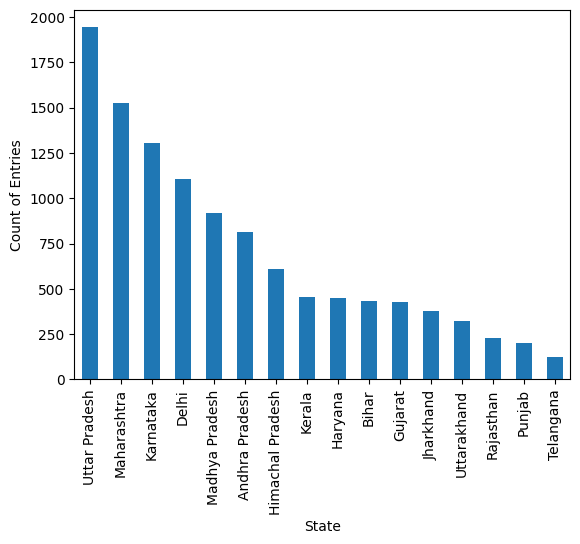

In [ ]:
# State count visualization
state_count = df['State'].value_counts()
state_count.plot(kind = 'bar')
plt.ylabel("Count of Entries")

Total sales per state

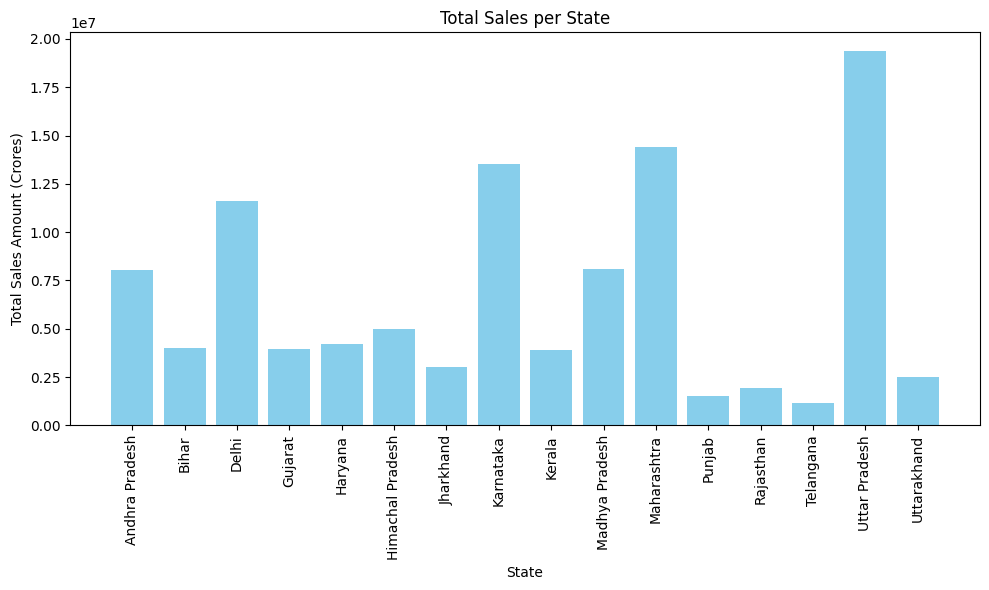

In [ ]:
total_sales_per_state = df.groupby('State')['Amount'].sum().reset_index()
total_sales_per_state.columns = ['State', 'Total_Sales']

# Bar chart for total sales by state
plt.figure(figsize=(10, 6))
plt.bar(total_sales_per_state['State'], total_sales_per_state['Total_Sales'], color='skyblue')
plt.title('Total Sales per State')
plt.xlabel('State')
plt.ylabel('Total Sales Amount (Crores)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Average order value per state

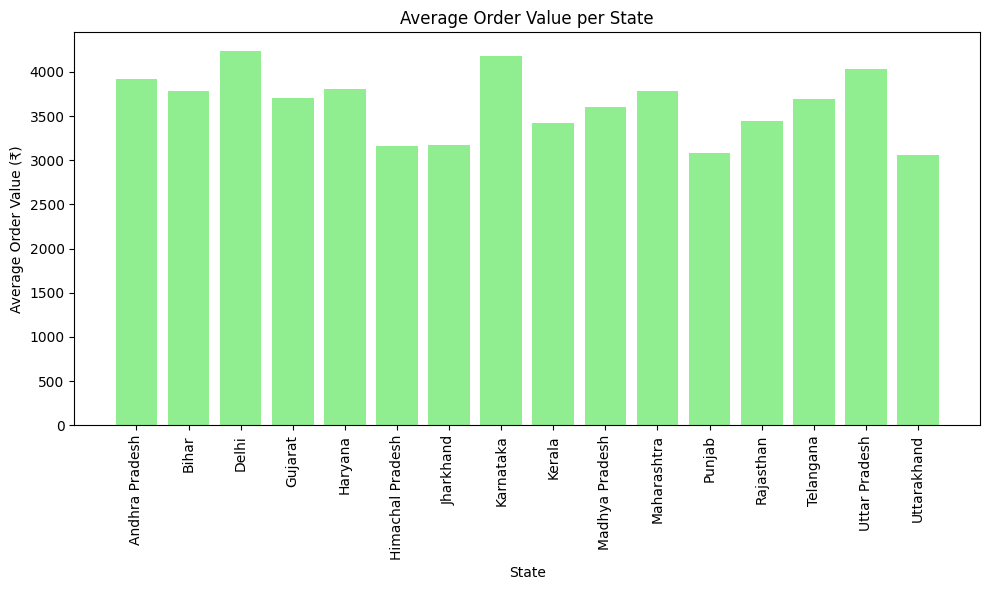

In [ ]:
average_order_value = df.groupby('State').agg({'Amount': 'sum', 'Orders': 'sum'}).reset_index()
average_order_value['Average_Order_Value'] = average_order_value['Amount'] / average_order_value['Orders']
average_order_value = average_order_value[['State', 'Average_Order_Value']]

# Bar chart for average order value by state
plt.figure(figsize=(10, 6))
plt.bar(average_order_value['State'], average_order_value['Average_Order_Value'], color='lightgreen')
plt.title('Average Order Value per State')
plt.xlabel('State')
plt.ylabel('Average Order Value (₹)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

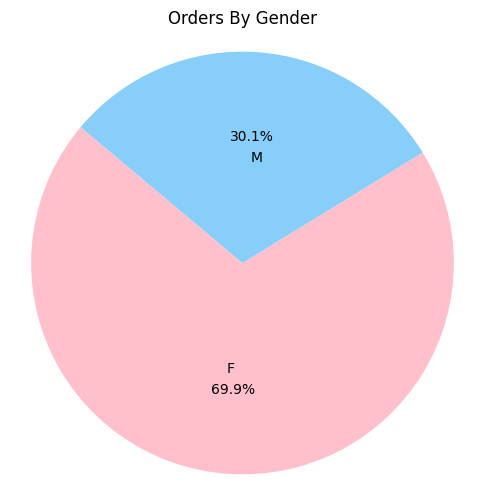

In [ ]:
# Orders by gender
orders_by_gender = df.groupby('Gender')['Orders'].sum().reset_index()

# Pie chart for orders by gender
plt.figure(figsize=(6, 6))
plt.pie(orders_by_gender['Orders'], labels=orders_by_gender['Gender'], autopct='%1.1f%%',colors=['pink','lightskyblue'], startangle=140,labeldistance=0.5)
plt.title('Orders By Gender')
plt.axis('equal')  # Equal aspect ratio ensures that pie chart is circular.
plt.show()

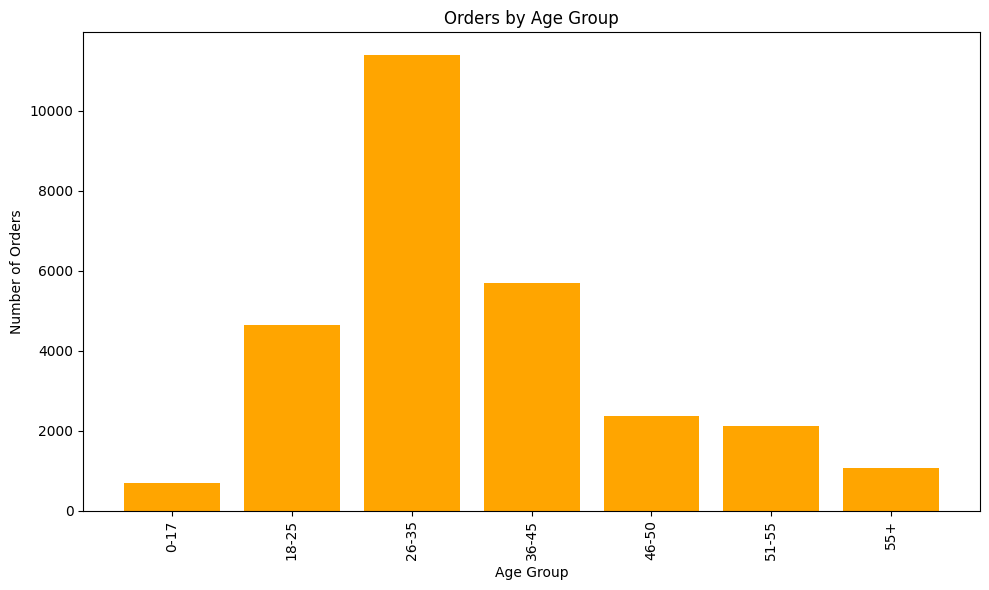

In [ ]:
# Orders by age group

orders_by_age_group = df.groupby('Age Group')['Orders'].sum().reset_index()

# Bar chart for orders by age group
plt.figure(figsize=(10, 6))
plt.bar(orders_by_age_group['Age Group'], orders_by_age_group['Orders'], color='orange')
plt.title('Orders by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Orders')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

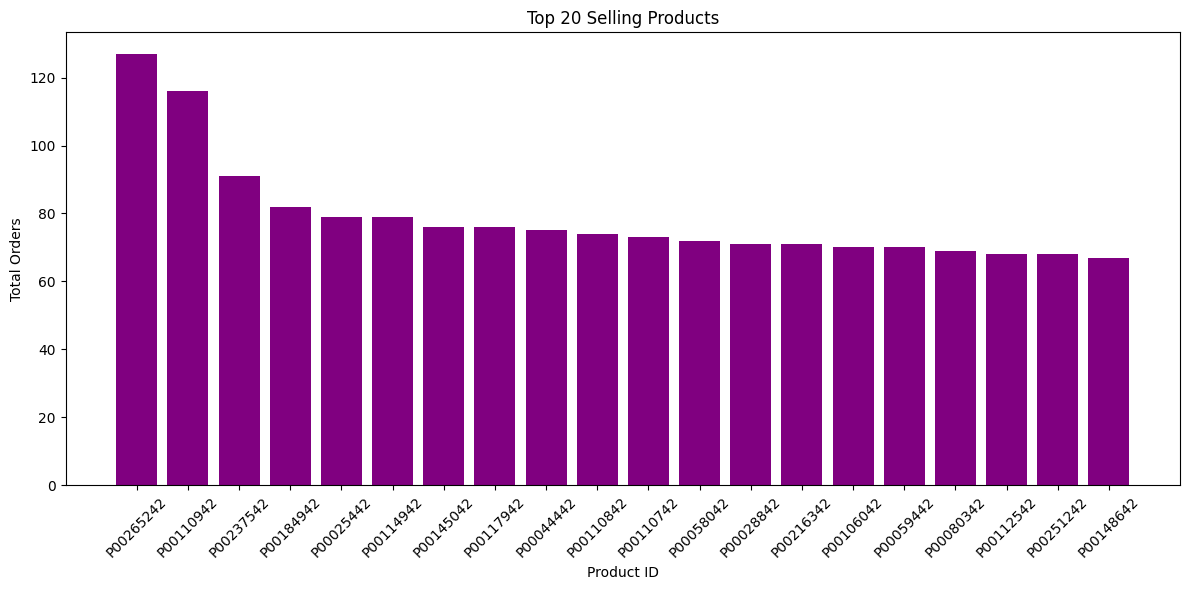

In [ ]:
# Analysis of top-selling products

top_products = df.groupby('Product_ID')['Orders'].sum().reset_index()
top_products.columns = ['Product_ID', 'Total_Orders']
top_products = top_products.sort_values(by='Total_Orders', ascending=False)

# Get the top 29 products
top_20_products = top_products.head(20)

# Bar chart for top-selling products
plt.figure(figsize=(12, 6))
plt.bar(top_20_products['Product_ID'], top_20_products['Total_Orders'], color='purple')
plt.title('Top 20 Selling Products')
plt.xlabel('Product ID')
plt.ylabel('Total Orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

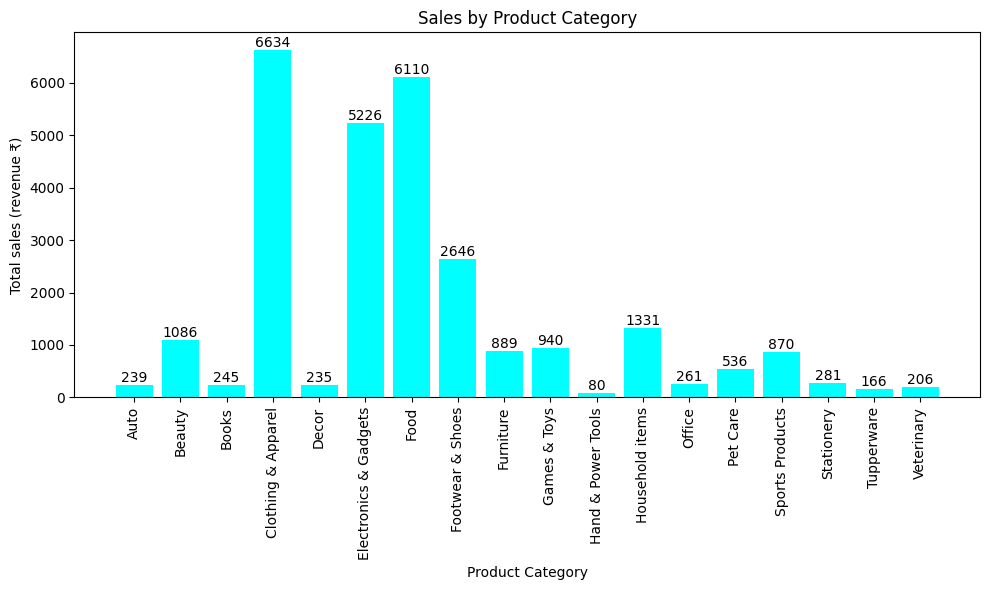

In [ ]:
# Sales by Product Category
sales_by_category = df.groupby('Product_Category').agg({'Orders': 'sum', 'Amount': 'sum'}).reset_index()

# Bar chart for sales by product category
plt.figure(figsize=(10, 6))
bars = plt.bar(sales_by_category['Product_Category'], sales_by_category['Orders'], color='cyan')

# Add labels
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height(),
             str(int(bar.get_height())),
             ha='center', va='bottom')

plt.title('Sales by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total sales (revenue ₹)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

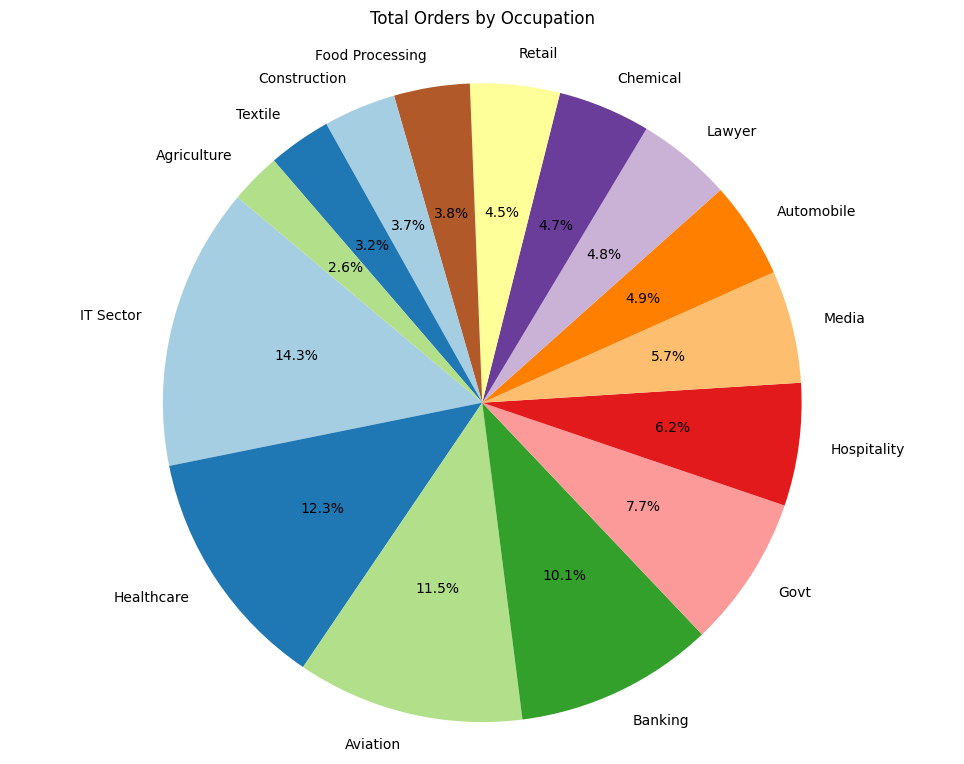

In [ ]:
# Total orders by occupation
occupation_orders = df.groupby('Occupation')['Orders'].sum().reset_index()
occupation_orders.columns = ['Occupation', 'Total_Orders']

# Sort values by Total Orders
occupation_orders = occupation_orders.sort_values(by='Total_Orders', ascending=False)

# Pie chart for orders by occupation
plt.figure(figsize=(10, 8))
plt.pie(
    occupation_orders['Total_Orders'],
    labels=occupation_orders['Occupation'],
    autopct='%1.1f%%',
    startangle=140,
    colors=plt.cm.Paired.colors
)
plt.title('Total Orders by Occupation', pad=20)  # Add padding to title
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.tight_layout(pad=2)  # Add some padding around the plot

plt.show()

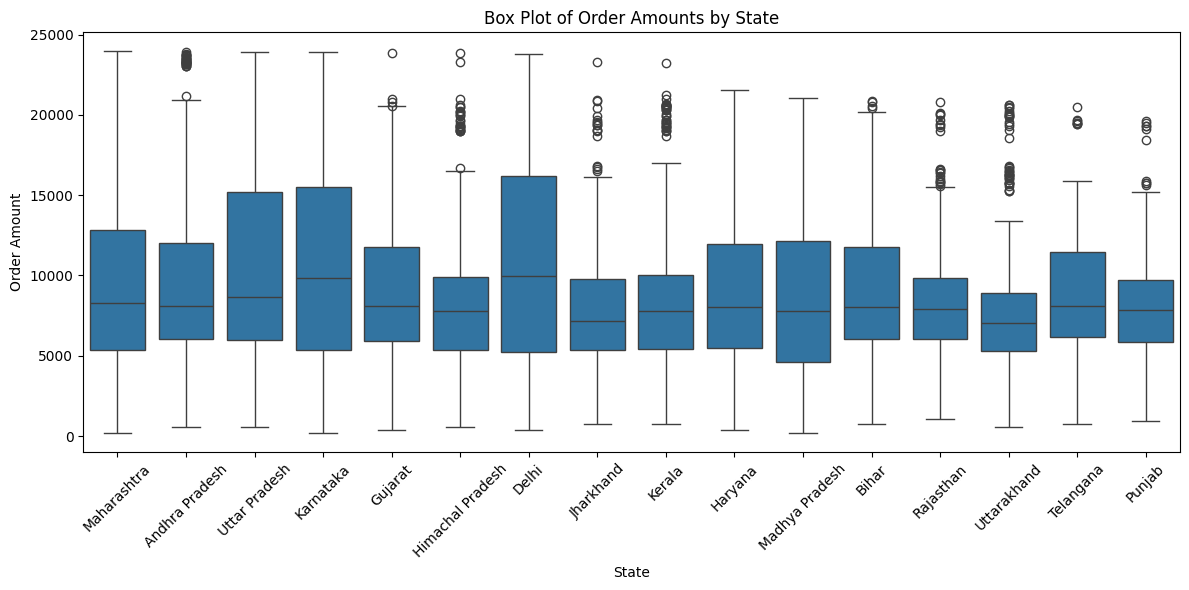

In [ ]:
# Box plot of order amounts by state

plt.figure(figsize=(12, 6))
sns.boxplot(x='State', y='Amount', data=df)
plt.title('Box Plot of Order Amounts by State')
plt.xlabel('State')
plt.ylabel('Order Amount')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

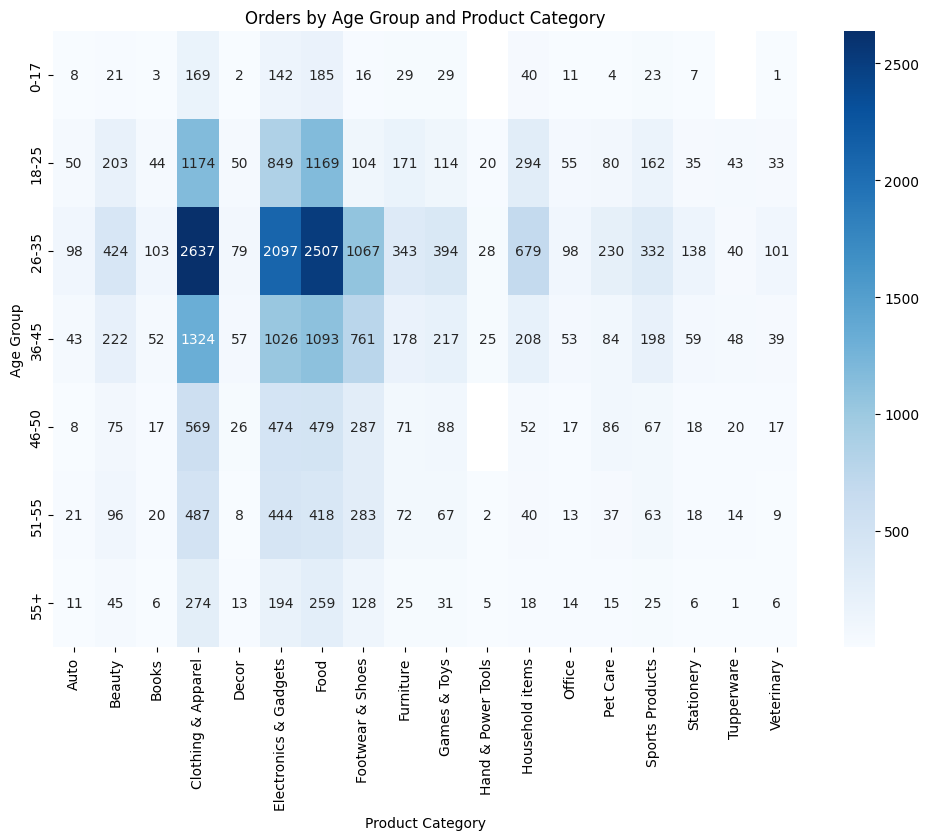

In [ ]:
# Orders by age group and product category

multi_group_orders = df.groupby(['Age Group', 'Product_Category'])['Orders'].sum().unstack()

# Heatmap for multivariate analysis
plt.figure(figsize=(12, 8))
sns.heatmap(multi_group_orders, cmap='Blues', annot=True, fmt='g')
plt.title('Orders by Age Group and Product Category')
plt.xlabel('Product Category')
plt.ylabel('Age Group')
plt.show()

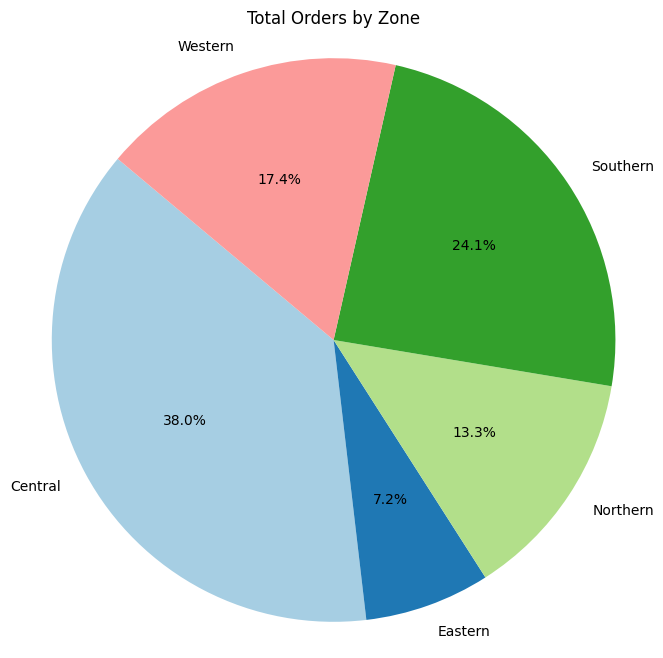

In [ ]:
# Total orders by zone
plt.figure(figsize=(8, 8))
plt.pie(zone_orders['Total_Orders'],
        labels=zone_orders['Zone'],
        autopct='%1.1f%%',
        startangle=140,
        colors=plt.cm.Paired.colors)

plt.title("Total Orders by Zone")
plt.axis('equal')
plt.show()

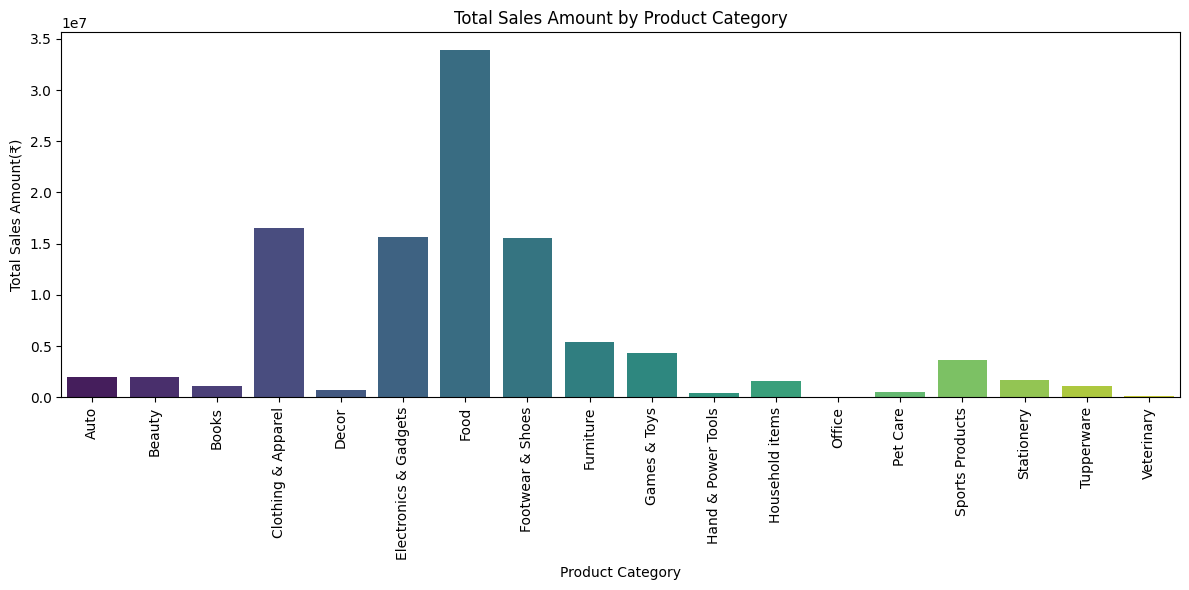

In [ ]:
# Total sales amount by product category
category_sales = df.groupby('Product_Category')['Amount'].sum().reset_index()
category_sales.columns = ['Product_Category', 'Total_Sales']

# Bar chart for total sales by product category
plt.figure(figsize=(12, 6))
sns.barplot(data=category_sales, x='Product_Category', y='Total_Sales',hue='Product_Category', palette='viridis',legend=False)
plt.title('Total Sales Amount by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Sales Amount(₹)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## Introduction to clustering for targeted marketing


In [ ]:
# Drop unnecessary columns and handle NaN values
df = df.drop(columns=['User_ID', 'Cust_name', 'Product_ID', 'Status', 'unnamed1', 'Zone', 'Orders'], errors='ignore')
df = df.dropna()

# Select the features for clustering (excluding `Amount` as it is our target to cluster on)
clustering_features = ['Gender', 'Age', 'Occupation', 'State', 'Product_Category']

# Define preprocessing steps for numerical and categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['Age']),  # Scale numerical features (only `Age` here)
        ('cat', OneHotEncoder(drop='first'), ['Gender','Occupation', 'State', 'Product_Category'])  # Encode categorical features
    ])

# Create a pipeline that includes preprocessing and KMeans clustering
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('kmeans', KMeans(n_clusters=4, random_state=42))  # Adjust n_clusters based on optimal selection
])

# Fit the pipeline on the selected features
pipeline.fit(df[clustering_features])

# Add the cluster labels to the original DataFrame
df['Demographic_Cluster'] = pipeline.predict(df[clustering_features])

# View cluster sizes to understand the distribution of data points across clusters
cluster_sizes = df['Demographic_Cluster'].value_counts()


In [ ]:
# Calculate and display the mean values for `Amount` by cluster to understand spending behavior
amount_summary = df.groupby('Demographic_Cluster')['Amount'].mean()

# Calculate and display the mean values for numeric features by cluster for interpretability
numeric_columns = ['Age']
cluster_summary = df.groupby('Demographic_Cluster')[numeric_columns].mean()

In [ ]:
# Analyze categorical features within each cluster
categorical_columns = ['Gender', 'Occupation', 'State', 'Product_Category']
categorical_summary = {}

for col in categorical_columns:
    categorical_summary[col] = df.groupby('Demographic_Cluster')[col].value_counts(normalize=True)

In [ ]:
# Set display options to avoid truncation
pd.set_option('display.max_rows', None)     # Show all rows
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.width', None)        # Do not truncate based on width

In [ ]:
# Display Cluster Sizes
print("Cluster Sizes:")
print(df['Demographic_Cluster'].value_counts())

Cluster Sizes:
Demographic_Cluster
1    6355
3    3862
0     650
2     372
Name: count, dtype: int64


In [ ]:
# Display mean values for `Amount` by cluster
print("\nAverage Amount Spent by Cluster:")
print(df.groupby('Demographic_Cluster')['Amount'].mean())


Average Amount Spent by Cluster:
Demographic_Cluster
0    9278.526154
1    9321.129338
2    9718.360215
3    9675.578325
Name: Amount, dtype: float64


In [ ]:
#Display mean values for numeric features by cluster
print("\nCluster Summary (Mean of Numeric Columns):")
print(df.groupby('Demographic_Cluster')['Age'].mean())


Cluster Summary (Mean of Numeric Columns):
Demographic_Cluster
0    28.727692
1    27.473800
2    76.153226
3    45.670378
Name: Age, dtype: float64


In [ ]:
# Display proportions of each categorical feature within each cluster
print("\nCategorical Summary by Cluster (Proportion of each category):")
for col in ['Gender','Occupation', 'State', 'Product_Category']:
    print(f"\n{col}:\n{df.groupby('Demographic_Cluster')[col].value_counts(normalize=True)}")


Categorical Summary by Cluster (Proportion of each category):

Gender:
Demographic_Cluster  Gender
0                    F         0.709231
                     M         0.290769
1                    F         0.701180
                     M         0.298820
2                    F         0.618280
                     M         0.381720
3                    F         0.695236
                     M         0.304764
Name: proportion, dtype: float64

Occupation:
Demographic_Cluster  Occupation     
0                    Lawyer             0.572308
                     IT Sector          0.067692
                     Healthcare         0.058462
                     Aviation           0.046154
                     Banking            0.041538
                     Media              0.038462
                     Chemical           0.032308
                     Retail             0.029231
                     Hospitality        0.024615
                     Automobile         0.020000
       